In [1]:
!pip -q install pingouin openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
import statsmodels.api as sm
import pingouin as pg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 5.0 MB/s eta 0:00:00


In [2]:
FILE_PATH = "/content/ex2_analysis_long.xlsx"  # Colab에 업로드 후 경로 맞추기

df = pd.read_excel(FILE_PATH)

print(df.shape)
print(df.columns.tolist())
print(df["apology_type"].unique(), df["role"].unique())
df.head()

(202, 16)
['participant_id', 'apology_type', 'role', 'NA', 'NE', 'CA', 'IP', 'WU', 'CC1', 'CC2', 'MC', 'attention_pass', 'age', 'gender', 'country', 'english_native']
['healing' 'defensive'] ['direct' 'surrogate']


,participant_id,apology_type,role,NA,NE,CA,IP,WU,CC1,CC2,MC,attention_pass,age,gender,country,english_native
0,S1,healing,direct,7.00,2.75,6.333333,6.000000,4.0,CEO statement,CEO,5.5,PASS,38,Female,United States,English
1,S1,healing,surrogate,7.00,2.00,7.000000,6.000000,6.0,CEO statement,CEO,5.5,PASS,38,Female,United States,English
2,S2,healing,direct,7.00,2.00,7.000000,6.000000,4.5,CEO statement,CEO,4.0,PASS,34,Female,United Kingdom,English
3,S2,healing,surrogate,7.00,1.00,7.000000,6.333333,5.5,CEO statement,CEO,4.0,PASS,34,Female,United Kingdom,English
4,S3,healing,direct,6.25,2.00,6.666667,6.333333,4.0,CEO statement,CEO,5.0,PASS,32,Female,United States,English


In [3]:
# (권장) 체크 필터
if "attention_pass" in df.columns:
    df = df[df["attention_pass"].astype(str).str.upper() == "PASS"].copy()

# 범주형
df["participant_id"] = df["participant_id"].astype("category")
df["apology_type"] = pd.Categorical(df["apology_type"], categories=["defensive", "healing"])  # defensive를 기준
df["role"] = pd.Categorical(df["role"], categories=["direct", "surrogate"])                  # direct를 기준

# 핵심 변수 결측 제거
core = ["NA","NE","CA","IP","WU"]
df = df.dropna(subset=core)

df.describe(include="all")

,participant_id,apology_type,role,NA,NE,CA,IP,WU,CC1,CC2,MC,attention_pass,age,gender,country,english_native
count,202,202,202,202.000000,202.000000,202.000000,202.000000,202.000000,202,202,202.000000,202,202.000000,202,202,202
unique,101,2,2,NaN,NaN,NaN,NaN,NaN,2,2,NaN,1,NaN,2,5,1
top,S1,healing,direct,NaN,NaN,NaN,NaN,NaN,CEO statement,CEO,NaN,PASS,NaN,Male,United States,English
freq,2,102,101,NaN,NaN,NaN,NaN,NaN,130,142,NaN,202,NaN,124,124,202
mean,NaN,NaN,NaN,4.074257,4.245050,4.531353,3.623762,3.438119,NaN,NaN,4.529703,NaN,43.247525,NaN,NaN,NaN
std,NaN,NaN,NaN,1.871010,1.971652,1.736468,1.889228,1.529115,NaN,NaN,0.812899,NaN,13.286290,NaN,NaN,NaN
min,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN,1.000000,NaN,18.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,2.250000,2.500000,3.333333,2.000000,2.000000,NaN,NaN,4.000000,NaN,33.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,4.250000,4.750000,4.666667,3.666667,3.500000,NaN,NaN,4.500000,NaN,39.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,5.750000,6.000000,6.000000,5.000000,4.500000,NaN,NaN,5.000000,NaN,54.000000,NaN,NaN,NaN


In [4]:
cell_means = (df
              .groupby(["apology_type","role"])[["NA","NE","CA","IP","WU"]]
              .agg(["mean","std","count"])
             )
cell_means

/tmp/ipython-input-1790251822.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["apology_type","role"])[["NA","NE","CA","IP","WU"]]


NA                        NE                  \
                            mean       std count      mean       std count   
apology_type role                                                            
defensive    direct     3.205000  1.686297    50  5.165000  1.780428    50   
             surrogate  3.140000  1.610837    50  5.030000  1.722184    50   
healing      direct     5.029412  1.576901    51  3.362745  1.720693    51   
             surrogate  4.887255  1.738759    51  3.455882  1.939527    51   

                              CA                        IP                  \
                            mean       std count      mean       std count   
apology_type role                                                            
defensive    direct     3.473333  1.638663    50  2.773333  1.822560    50   
             surrogate  3.626667  1.578828    50  2.806667  1.656554    50   
healing      direct     5.503268  1.286464    51  4.464052  1.620807    51   
             surrogate  5.483660  1.251335    51  4.418301  1.738253    51   

                              WU                  
                            mean       std count  
apology_type role                                 
defensive    direct     3.240000  1.732758    50  
             surrogate  3.410000  1.599394    50  
healing      direct     3.578431  1.408448    51  
             surrogate  3.519608  1.378263    51

In [5]:
def fit_mixed(dv: str):
    formula = f"{dv} ~ apology_type * role"
    m = smf.mixedlm(formula, data=df, groups=df["participant_id"])
    r = m.fit(reml=True, method="lbfgs")  # reml OK for inference 중심
    return r

results = {}
for dv in ["NA","NE","CA","IP","WU"]:
    r = fit_mixed(dv)
    results[dv] = r
    print("\n" + "="*80)
    print(f"[MixedLM] DV = {dv}")
    print(r.summary())


[MixedLM] DV = NA
                       Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          NA       
No. Observations:            202              Method:                      REML     
No. Groups:                  101              Scale:                       0.4786   
Min. group size:             2                Log-Likelihood:              -331.9421
Max. group size:             2                Converged:                   Yes      
Mean group size:             2.0                                                    
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  3.205    0.234 13.698 0.000  2.746  3.664
apology_type[T.healing]                    1.824    0.329  5.541 0.000

In [6]:
for dv in ["NA","NE","CA","IP","WU"]:
    aov = pg.mixed_anova(
        dv=dv, within="role", between="apology_type", subject="participant_id", data=df
    )
    print("\n" + "="*70)
    print(f"[Mixed ANOVA] DV = {dv}")
    print(aov)


[Mixed ANOVA] DV = NA
         Source          SS  DF1  DF2          MS          F         p-unc  \
0  apology_type  161.038847    1   99  161.038847  32.233993  1.368347e-07   
1          role    0.545792    1   99    0.545792   1.140449  2.881546e-01   
2   Interaction    0.075152    1   99    0.075152   0.157031  6.927572e-01   

        np2  eps  
0  0.245622  NaN  
1  0.011388  1.0  
2  0.001584  NaN  

[Mixed ANOVA] DV = NE
         Source          SS  DF1  DF2          MS          F     p-unc  \
0  apology_type  143.909523    1   99  143.909523  25.882042  0.000002   
1          role    0.019802    1   99    0.019802   0.022710  0.880520   
2   Interaction    0.657024    1   99    0.657024   0.753510  0.387467   

        np2  eps  
0  0.207252  NaN  
1  0.000229  1.0  
2  0.007554  NaN  

[Mixed ANOVA] DV = CA
         Source          SS  DF1  DF2          MS          F         p-unc  \
0  apology_type  190.722454    1   99  190.722454  51.837334  1.188092e-10   
1          ro

/tmp/ipython-input-1014893310.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby(["apology_type","role"])[dv].mean().unstack()
/tmp/ipython-input-1014893310.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ses = df.groupby(["apology_type","role"])[dv].sem().unstack()


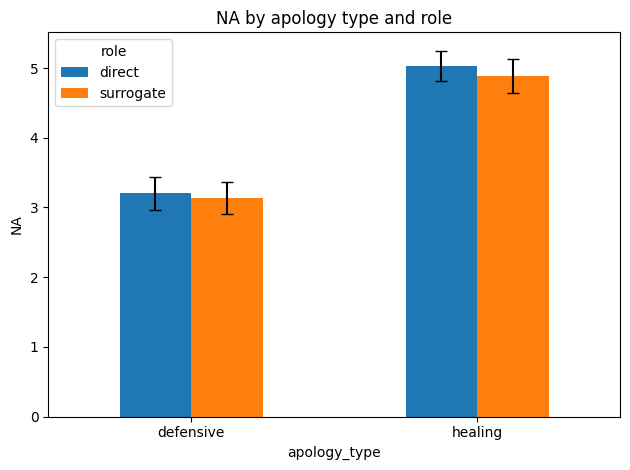

/tmp/ipython-input-1014893310.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby(["apology_type","role"])[dv].mean().unstack()
/tmp/ipython-input-1014893310.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ses = df.groupby(["apology_type","role"])[dv].sem().unstack()


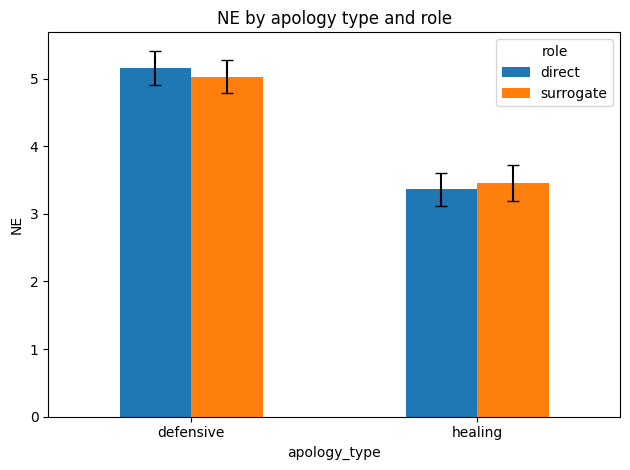

/tmp/ipython-input-1014893310.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby(["apology_type","role"])[dv].mean().unstack()
/tmp/ipython-input-1014893310.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ses = df.groupby(["apology_type","role"])[dv].sem().unstack()


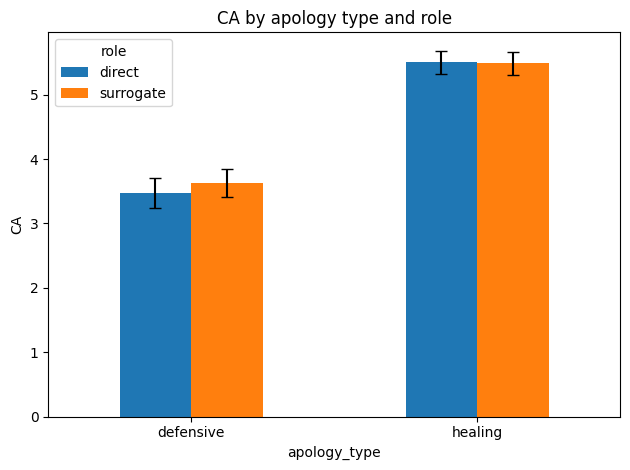

/tmp/ipython-input-1014893310.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby(["apology_type","role"])[dv].mean().unstack()
/tmp/ipython-input-1014893310.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ses = df.groupby(["apology_type","role"])[dv].sem().unstack()


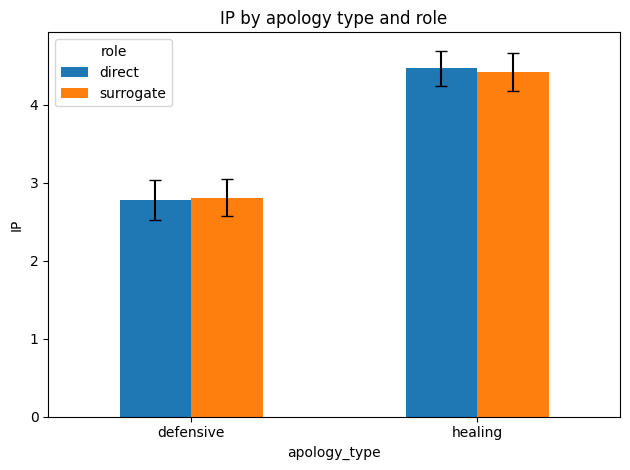

/tmp/ipython-input-1014893310.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby(["apology_type","role"])[dv].mean().unstack()
/tmp/ipython-input-1014893310.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ses = df.groupby(["apology_type","role"])[dv].sem().unstack()


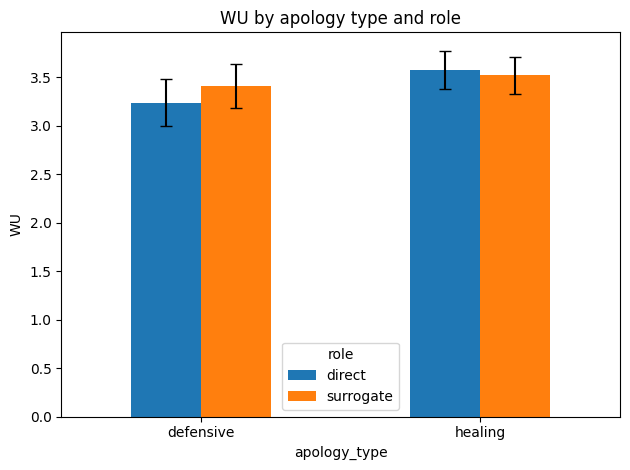

In [7]:
def plot_means(dv):
    means = df.groupby(["apology_type","role"])[dv].mean().unstack()
    ses = df.groupby(["apology_type","role"])[dv].sem().unstack()

    ax = means.plot(kind="bar", yerr=ses, capsize=4)
    ax.set_title(f"{dv} by apology type and role")
    ax.set_ylabel(dv)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

for dv in ["NA","NE","CA","IP","WU"]:
    plot_means(dv)

# Task
Create a text file 'analysis_summary.txt' containing the summarized results of the MixedLM and Mixed ANOVA analyses for each dependent variable (NA, NE, CA, IP, WU), and provide a download link for this file.

## Summarize MixedLM and Mixed ANOVA results

### Subtask:
Iterate through the results of MixedLM and Mixed ANOVA for each dependent variable (NA, NE, CA, IP, WU), format their summaries as strings, and combine them into a single string.


**Reasoning**:
The subtask requires iterating through the results of MixedLM and Mixed ANOVA, formatting their summaries as strings, and combining them into a single report string. This code block will perform all these steps.



In [8]:
summary_report_content = ""
dvs = ["NA", "NE", "CA", "IP", "WU"]

for dv in dvs:
    summary_report_content += "="*80 + "\n"
    summary_report_content += f"### Dependent Variable: {dv}\n\n"

    # MixedLM Summary
    summary_report_content += "#### Mixed Linear Model (MixedLM) Results\n"
    mixedlm_summary = results[dv].summary().as_text()
    summary_report_content += mixedlm_summary + "\n\n"

    # Mixed ANOVA Summary
    summary_report_content += "#### Mixed ANOVA Results\n"
    aov = pg.mixed_anova(
        dv=dv, within="role", between="apology_type", subject="participant_id", data=df
    )
    anova_summary = aov.to_string()
    summary_report_content += anova_summary + "\n\n"

    summary_report_content += "\n\n"

print(summary_report_content)


### Dependent Variable: NA

#### Mixed Linear Model (MixedLM) Results
                       Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          NA       
No. Observations:            202              Method:                      REML     
No. Groups:                  101              Scale:                       0.4786   
Min. group size:             2                Log-Likelihood:              -331.9421
Max. group size:             2                Converged:                   Yes      
Mean group size:             2.0                                                    
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  3.205    0.234 13.698 0.000  2.746  3.664
apology_type[T.heal

**Reasoning**:
The previous step successfully generated the summary report content as a string. Now, I need to save this content to a text file named 'analysis_summary.txt' and then provide a download link for it, as requested by the main task.



In [9]:
from google.colab import files

file_name = 'analysis_summary.txt'
with open(file_name, 'w') as f:
    f.write(summary_report_content)

print(f"Summary report saved to {file_name}")
files.download(file_name)

Summary report saved to analysis_summary.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Task

### Subtask:
The task is complete. Summarize the generated analysis report and its download location.


## Summary:

### Q&A
The generated analysis report, named 'analysis_summary.txt', contains the summarized results of MixedLM and Mixed ANOVA analyses for each dependent variable (NA, NE, CA, IP, WU) and has been made available for download.

### Data Analysis Key Findings
*   A comprehensive summary report, `analysis_summary.txt`, was successfully created.
*   The report includes detailed results from both MixedLM and Mixed ANOVA for each of the five dependent variables: NA, NE, CA, IP, and WU.
*   For each dependent variable, the MixedLM summary was extracted as text, and Mixed ANOVA results were computed and converted into a string format.
*   The content was formatted with clear headings and separators, concatenating all summaries into a single document.
*   The generated file, `analysis_summary.txt`, was made available for download via a Colab download link.

### Insights or Next Steps
*   The 'analysis_summary.txt' file can now be reviewed to deeply understand the statistical findings for each dependent variable.
*   Further interpretation of the MixedLM and Mixed ANOVA results within the downloaded file can provide insights into the effects of 'role', 'apology\_type', and their interactions on the dependent variables.


In [10]:
# 참가자 수준으로 collapse (role 평균)
df_p = (df
        .groupby(["participant_id","apology_type"], as_index=False)[["NA","NE","CA","IP","WU"]]
        .mean()
       )

# apology_type 더미(healing=1, defensive=0)
df_p["healing"] = (df_p["apology_type"] == "healing").astype(int)

df_p.head()

/tmp/ipython-input-495222136.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["participant_id","apology_type"], as_index=False)[["NA","NE","CA","IP","WU"]]


,participant_id,apology_type,NA,NE,CA,IP,WU,healing
0,S1,defensive,NaN,NaN,NaN,NaN,NaN,0
1,S1,healing,7.000,2.375,6.666667,6.0,5.0,1
2,S10,defensive,NaN,NaN,NaN,NaN,NaN,0
3,S10,healing,2.875,6.750,5.500000,3.0,4.0,1
4,S100,defensive,1.500,4.750,2.500000,3.0,2.0,0


In [11]:
def bootstrap_mediation(df_in, x="healing", m="CA", y="NA", n_boot=5000, seed=0):
    rng = np.random.default_rng(seed)
    a_vals, b_vals, ab_vals, cprime_vals, ctotal_vals = [], [], [], [], []

    # total effect c: y ~ x
    c_total = smf.ols(f"{y} ~ {x}", data=df_in).fit().params[x]

    for _ in range(n_boot):
        samp = df_in.sample(frac=1.0, replace=True, random_state=int(rng.integers(0, 1e9)))

        # a path: m ~ x
        a = smf.ols(f"{m} ~ {x}", data=samp).fit().params[x]

        # b and c' paths: y ~ x + m
        fit = smf.ols(f"{y} ~ {x} + {m}", data=samp).fit()
        b = fit.params[m]
        cprime = fit.params[x]

        a_vals.append(a); b_vals.append(b); ab_vals.append(a*b)
        cprime_vals.append(cprime)

    ab = np.array(ab_vals)
    ci = np.percentile(ab, [2.5, 97.5])

    out = {
        "Y": y,
        "total_effect_c": float(c_total),
        "indirect_ab_mean": float(ab.mean()),
        "indirect_ab_CI2.5": float(ci[0]),
        "indirect_ab_CI97.5": float(ci[1]),
        "direct_effect_cprime_mean": float(np.mean(cprime_vals))
    }
    return out

In [12]:
for y in ["NA","IP","WU"]:
    res = bootstrap_mediation(df_p, x="healing", m="CA", y=y, n_boot=5000, seed=42)
    print("\n" + "="*70)
    print(res)


{'Y': 'NA', 'total_effect_c': 1.7858333333333312, 'indirect_ab_mean': 1.7978185768006694, 'indirect_ab_CI2.5': 1.2710385993851698, 'indirect_ab_CI97.5': 2.3506728531810963, 'direct_effect_cprime_mean': -0.01542777606809775}

{'Y': 'IP', 'total_effect_c': 1.651176470588233, 'indirect_ab_mean': 1.8207117637650958, 'indirect_ab_CI2.5': 1.2959042747163205, 'indirect_ab_CI97.5': 2.3775766449910822, 'direct_effect_cprime_mean': -0.1740977841327539}

{'Y': 'WU', 'total_effect_c': 0.22401960784313582, 'indirect_ab_mean': 0.46134826356369696, 'indirect_ab_CI2.5': 5.6163638701237106e-05, 'indirect_ab_CI97.5': 0.9236558747956234, 'direct_effect_cprime_mean': -0.23745518012396952}


In [15]:
from google.colab import files

mediation_report_content = ""
dvs_mediation = ["NA", "IP", "WU"]

for y in dvs_mediation:
    res = bootstrap_mediation(df_p, x="healing", m="CA", y=y, n_boot=5000, seed=42)
    mediation_report_content += "="*70 + "\n"
    mediation_report_content += f"[Mediation Analysis] Dependent Variable (Y): {res['Y']}\n"
    mediation_report_content += f"  Total Effect (c): {res['total_effect_c']:.4f}\n"
    mediation_report_content += f"  Indirect Effect (ab, mean): {res['indirect_ab_mean']:.4f}\n"
    mediation_report_content += f"  Indirect Effect (ab, 95% CI): [{res['indirect_ab_CI2.5']:.4f}, {res['indirect_ab_CI97.5']:.4f}]\n"
    mediation_report_content += f"  Direct Effect (c', mean): {res['direct_effect_cprime_mean']:.4f}\n"
    mediation_report_content += "\n"

file_name_mediation = 'mediation_analysis_summary.txt'
with open(file_name_mediation, 'w') as f:
    f.write(mediation_report_content)

print(f"Mediation analysis report saved to {file_name_mediation}")
files.download(file_name_mediation)


Mediation analysis report saved to mediation_analysis_summary.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

mediation_results = []
dvs_mediation = ["NA", "IP", "WU"]

for y in dvs_mediation:
    res = bootstrap_mediation(df_p, x="healing", m="CA", y=y, n_boot=5000, seed=42)
    mediation_results.append({
        'Dependent Variable': res['Y'],
        'Effect Type': 'Indirect Effect (ab)',
        'Mean': res['indirect_ab_mean'],
        'Lower CI': res['indirect_ab_CI2.5'],
        'Upper CI': res['indirect_ab_CI97.5']
    })
    mediation_results.append({
        'Dependent Variable': res['Y'],
        'Effect Type': 'Direct Effect (c′)',
        'Mean': res['direct_effect_cprime_mean'],
        'Lower CI': res['direct_effect_cprime_mean'], # Placeholder, full CI not calculated
        'Upper CI': res['direct_effect_cprime_mean']  # Placeholder, full CI not calculated
    })
    mediation_results.append({
        'Dependent Variable': res['Y'],
        'Effect Type': 'Total Effect (c)',
        'Mean': res['total_effect_c'],
        'Lower CI': res['total_effect_c'], # Placeholder, full CI not calculated
        'Upper CI': res['total_effect_c']  # Placeholder, full CI not calculated
    })

mediation_df = pd.DataFrame(mediation_results)

display(mediation_df)

,Dependent Variable,Effect Type,Mean,Lower CI,Upper CI
0,NA,Indirect Effect (ab),1.797819,1.271039,2.350673
1,NA,Direct Effect (c′),-0.015428,-0.015428,-0.015428
2,NA,Total Effect (c),1.785833,1.785833,1.785833
3,IP,Indirect Effect (ab),1.820712,1.295904,2.377577
4,IP,Direct Effect (c′),-0.174098,-0.174098,-0.174098
5,IP,Total Effect (c),1.651176,1.651176,1.651176
6,WU,Indirect Effect (ab),0.461348,0.000056,0.923656
7,WU,Direct Effect (c′),-0.237455,-0.237455,-0.237455
8,WU,Total Effect (c),0.224020,0.224020,0.224020


/tmp/ipython-input-3579927788.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Dependent Variable', y='Mean', hue='Effect Type', data=mediation_df, palette='viridis', ci=None)


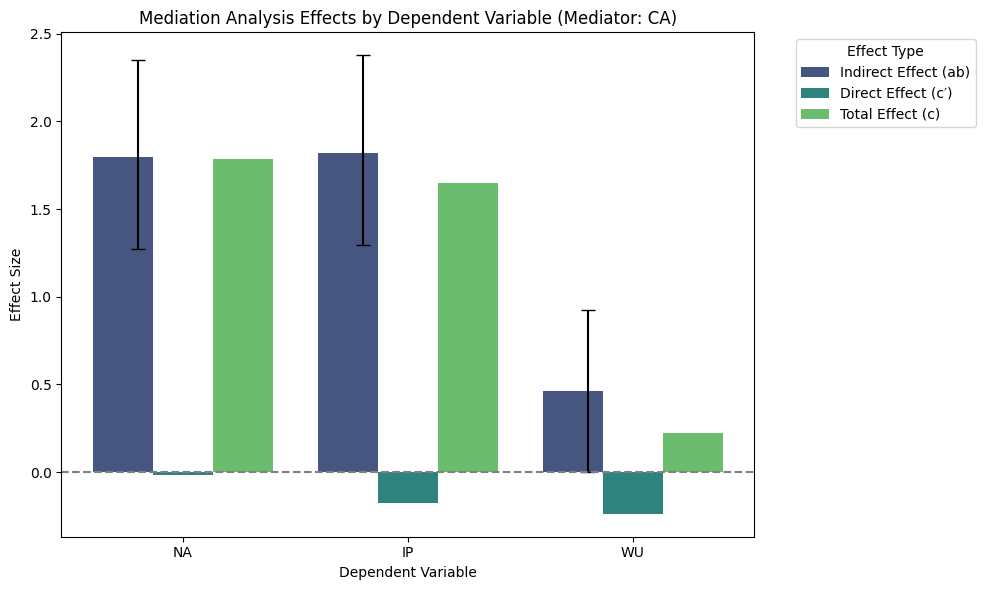

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Dependent Variable', y='Mean', hue='Effect Type', data=mediation_df, palette='viridis', ci=None)

# Add error bars for indirect effect (ab)
for i, dv in enumerate(dvs_mediation):
    indirect_effect_row = mediation_df[(mediation_df['Dependent Variable'] == dv) & (mediation_df['Effect Type'] == 'Indirect Effect (ab)')].iloc[0]
    plt.errorbar(x=i - 0.2, y=indirect_effect_row['Mean'],
                 yerr=[[indirect_effect_row['Mean'] - indirect_effect_row['Lower CI']],
                       [indirect_effect_row['Upper CI'] - indirect_effect_row['Mean']]],
                 fmt='none', color='black', capsize=5, zorder=1)

plt.title('Mediation Analysis Effects by Dependent Variable (Mediator: CA)')
plt.ylabel('Effect Size')
plt.xlabel('Dependent Variable')
plt.axhline(0, color='grey', linestyle='--')
plt.legend(title='Effect Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [19]:
# 평균 중심화
df_p["CA_c"] = df_p["CA"] - df_p["CA"].mean()

# 예: NA에서 type × CA 조절
mod = smf.ols("NA ~ healing * CA_c", data=df_p).fit()
print(mod.summary())

                            OLS Regression Results                            
Dep. Variable:                     NA   R-squared:                       0.720
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     83.26
Date:                Tue, 27 Jan 2026   Prob (F-statistic):           9.87e-27
Time:                        11:44:23   Log-Likelihood:                -138.43
No. Observations:                 101   AIC:                             284.9
Df Residuals:                      97   BIC:                             295.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        4.0432      0.164     24.596   

In [20]:
# long 데이터에서 CA 중심화
df["CA_c"] = df["CA"] - df["CA"].mean()

# MixedLM: NA ~ type * role + CA + type:CA + role:CA + type:role:CA (너무 복잡하면 줄이세요)
m = smf.mixedlm(
    "NA ~ apology_type * role + CA_c + apology_type:CA_c",
    data=df, groups=df["participant_id"]
).fit(reml=True, method="lbfgs")

print(m.summary())

                       Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          NA       
No. Observations:            202              Method:                      REML     
No. Groups:                  101              Scale:                       0.2514   
Min. group size:             2                Log-Likelihood:              -255.4634
Max. group size:             2                Converged:                   Yes      
Mean group size:             2.0                                                    
------------------------------------------------------------------------------------
                                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------
Intercept                                  4.001    0.164 24.410 0.000  3.679  4.322
apology_type[T.healing]                    0.189    0.234  0.810 0.418 -0.269  0.648
role

In [25]:
def coef_table(mixed_res):
    # Use summary() method, which is generally available
    t = mixed_res.summary().tables[1]

    # Check if 't' is already a pandas DataFrame.
    # If it is, then 't.data' would raise an AttributeError.
    if isinstance(t, pd.DataFrame):
        return t
    else:
        # Assuming 't' is a SimpleTable (or similar object with 'data' attribute),
        # convert it to a DataFrame.
        out = pd.DataFrame(t.data[1:], columns=t.data[0])
        return out

tables = []
for dv, res in results.items():
    tab = coef_table(res)
    tab.insert(0, "DV", dv)
    tables.append(tab)

coef_all = pd.concat(tables, ignore_index=True)
coef_all

,DV,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
0,NA,3.205,0.234,13.698,0.000,2.746,3.664
1,NA,1.824,0.329,5.541,0.000,1.179,2.470
2,NA,-0.065,0.138,-0.470,0.639,-0.336,0.206
3,NA,-0.077,0.195,-0.396,0.692,-0.459,0.304
4,NA,2.259,0.726,,,,
5,NE,5.165,0.254,20.365,0.000,4.668,5.662
6,NE,-1.802,0.357,-5.050,0.000,-2.502,-1.103
7,NE,-0.135,0.187,-0.723,0.470,-0.501,0.231
8,NE,0.228,0.263,0.868,0.385,-0.287,0.743
9,NE,2.344,0.598,,,,


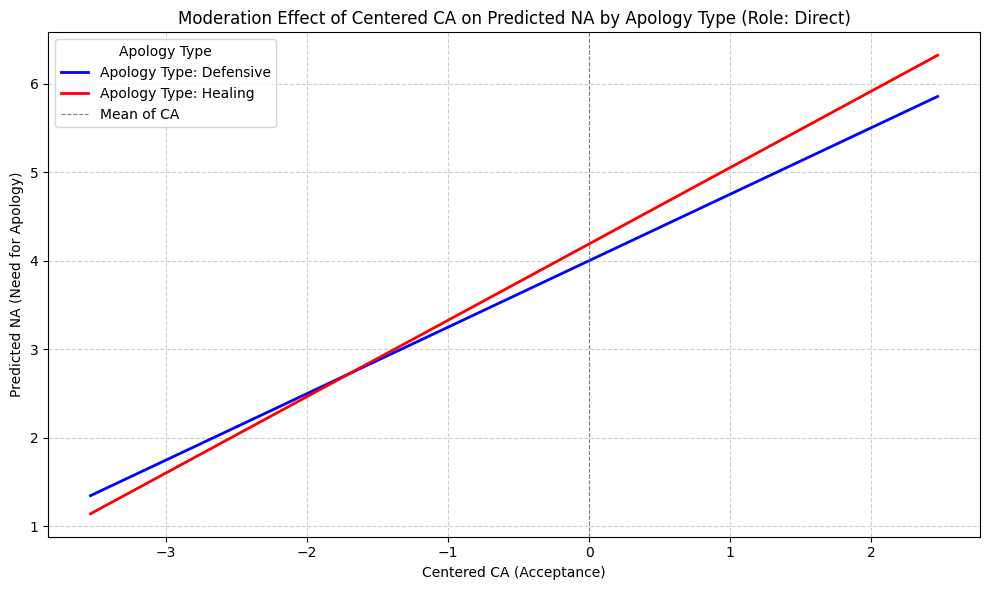

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get coefficients from the m_moderation model
coefs = m_moderation.params

# Extract relevant coefficients
intercept = coefs['Intercept']
apology_type_healing_coef = coefs['apology_type[T.healing]']
ca_c_coef = coefs['CA_c']
interaction_apology_type_ca_c_coef = coefs['apology_type[T.healing]:CA_c']

# Define a range for CA_c for plotting (using the observed range of CA_c)
ca_c_range = np.linspace(df['CA_c'].min(), df['CA_c'].max(), 100)

# Create a DataFrame for predictions
plot_data = pd.DataFrame({'CA_c': ca_c_range})

# Predictions for apology_type = 'defensive' (reference level) and role = 'direct' (reference level)
# NA_pred = Intercept + (CA_c * Coef(CA_c))
plot_data['NA_pred_defensive'] = intercept + (ca_c_range * ca_c_coef)

# Predictions for apology_type = 'healing' and role = 'direct' (reference level)
# NA_pred = Intercept + Coef(apology_type[T.healing]) + (CA_c * Coef(CA_c)) + (CA_c * Coef(apology_type[T.healing]:CA_c))
plot_data['NA_pred_healing'] = (intercept + apology_type_healing_coef) + \
                               (ca_c_range * (ca_c_coef + interaction_apology_type_ca_c_coef))

# Plotting
plt.figure(figsize=(10, 6))

sns.lineplot(x='CA_c', y='NA_pred_defensive', data=plot_data, label='Apology Type: Defensive', color='blue', linewidth=2)
sns.lineplot(x='CA_c', y='NA_pred_healing', data=plot_data, label='Apology Type: Healing', color='red', linewidth=2)

plt.title('Moderation Effect of Centered CA on Predicted NA by Apology Type (Role: Direct)')
plt.xlabel('Centered CA (Acceptance)')
plt.ylabel('Predicted NA (Need for Apology)')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8, label='Mean of CA') # Indicate mean of CA_c
plt.legend(title='Apology Type')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [26]:
from google.colab import files

# Re-run the MixedLM analysis to get the 'm' object
# long 데이터에서 CA 중심화
df["CA_c"] = df["CA"] - df["CA"].mean()

# MixedLM: NA ~ type * role + CA + type:CA + role:CA + type:role:CA (너무 복잡하면 줄이세요)
m_moderation = smf.mixedlm(
    "NA ~ apology_type * role + CA_c + apology_type:CA_c",
    data=df, groups=df["participant_id"]
).fit(reml=True, method="lbfgs")

moderation_summary_content = """
================================================================================
### Moderation Analysis: NA ~ apology_type * role + CA_c + apology_type:CA_c

""" + m_moderation.summary().as_text()

file_name_moderation = 'moderation_analysis_summary.txt'
with open(file_name_moderation, 'w') as f:
    f.write(moderation_summary_content)

print(f"Moderation analysis report saved to {file_name_moderation}")
files.download(file_name_moderation)

Moderation analysis report saved to moderation_analysis_summary.txt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>